In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# POST-PCA

In [ ]:
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import f1_score , confusion_matrix , classification_report
from xgboost import XGBClassifier
import os
import pickle as pk
import seaborn as sb
import matplotlib.pyplot as plt

In [ ]:
CURR_DIR = os.getcwd()
DATA_DIR = os.path.join(CURR_DIR , 'drive' , 'MyDrive' , 'Codon_Usage_dataset')
PCA_FILE_NAME = "pca_results.csv"
PCA_PATH = os.path.join(DATA_DIR , PCA_FILE_NAME)
OUTPUT_PATH = DATA_DIR

In [ ]:
pca_data = pd.read_csv(PCA_PATH)
pca_data

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,Kingdom
0,5.999607,-0.110518,3.624183,-2.226701,0.959577,1.476934,-0.252336,-0.708389,-0.505336,-1.730777,...,-0.872885,-1.447775,0.054360,-0.089393,-0.424739,-0.837635,-0.514593,0.471557,-0.290105,vrl
1,5.585957,-0.273068,4.076570,-1.804301,-0.747029,1.178151,-1.544513,-1.309988,-0.412640,-1.676344,...,-0.076676,-0.045823,0.511744,-0.339438,-0.561600,-0.051212,0.962530,-0.322449,0.141626,vrl
2,-0.274695,-2.535389,1.838187,-2.299159,0.415666,-0.364983,-0.243076,0.255400,0.459756,0.439171,...,-0.981680,0.143479,-0.710796,-0.968506,-0.507073,0.023495,0.094500,0.387273,0.200335,vrl
3,-1.616704,-2.118830,1.556229,-1.328989,-0.272819,2.135633,-0.070702,-0.155886,0.617887,-1.513015,...,-0.295139,0.451240,-0.533989,0.252502,-1.034724,0.694537,-0.262238,0.909396,0.805527,vrl
4,-0.786983,-4.976234,0.499870,0.221165,0.152280,0.011056,0.056625,-0.583426,-0.031140,-0.958820,...,-0.499746,-0.530838,-0.699213,0.730259,0.873118,0.765742,0.135460,-0.745189,-0.348492,vrl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13005,1.488028,-1.285673,2.506186,-2.594555,-0.033034,0.214512,-1.256892,0.289318,-0.245747,1.154231,...,1.379061,-0.929496,-0.105079,0.286591,0.384934,0.145774,0.235111,0.525128,1.269992,mam
13006,0.942722,7.180218,0.446369,0.270972,-0.215830,-0.172294,-1.108029,0.695637,0.060012,-0.376058,...,-0.596185,-0.247884,-0.328866,0.793225,-0.236648,-0.166733,-0.340554,0.262782,0.271341,mam
13007,1.091028,8.259384,0.200550,0.444341,-0.787122,-1.463038,-1.210190,1.284691,0.555139,-0.474701,...,-1.019093,0.094483,-0.018001,0.777968,0.648920,-0.237344,0.283081,-0.044386,0.123673,mam
13008,2.432261,-1.167826,1.805895,-1.741807,0.323634,0.848070,-0.196708,0.921848,-0.755293,0.161436,...,0.131042,-0.313954,-0.500590,-0.105909,0.307786,0.283756,-0.037844,0.212148,-0.208889,mam


In [ ]:
X , Y = pca_data.iloc[: , :-1] , pca_data.iloc[: , -1]
X , Y

(            PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
 0      5.999607 -0.110518  3.624183 -2.226701  0.959577  1.476934 -0.252336   
 1      5.585957 -0.273068  4.076570 -1.804301 -0.747029  1.178151 -1.544513   
 2     -0.274695 -2.535389  1.838187 -2.299159  0.415666 -0.364983 -0.243076   
 3     -1.616704 -2.118830  1.556229 -1.328989 -0.272819  2.135633 -0.070702   
 4     -0.786983 -4.976234  0.499870  0.221165  0.152280  0.011056  0.056625   
 ...         ...       ...       ...       ...       ...       ...       ...   
 13005  1.488028 -1.285673  2.506186 -2.594555 -0.033034  0.214512 -1.256892   
 13006  0.942722  7.180218  0.446369  0.270972 -0.215830 -0.172294 -1.108029   
 13007  1.091028  8.259384  0.200550  0.444341 -0.787122 -1.463038 -1.210190   
 13008  2.432261 -1.167826  1.805895 -1.741807  0.323634  0.848070 -0.196708   
 13009  0.335443  6.675303  0.278048  0.355334  0.076834  0.100802 -0.855018   
 
             PC8       PC9      PC10  

In [ ]:
y_set = sorted(list(set(Y)))
kingdom_map = {}
for i in range(len(y_set)):
    kingdom_map[y_set[i]] = i

kingdom_map

{'arc': 0,
 'bct': 1,
 'inv': 2,
 'mam': 3,
 'phg': 4,
 'pln': 5,
 'vrl': 6,
 'vrt': 7}

In [ ]:
def kingdom_mapping(kingdom):
  return kingdom_map[kingdom]

In [ ]:
Y = Y.map(kingdom_mapping)

In [ ]:
X_train, X_test , y_train, y_test = train_test_split(X , Y , test_size = 0.2 ,  stratify = Y , random_state = 42)

In [ ]:
model_grid_serach = XGBClassifier(n_estimators = 100)


param_grid = {
    'max_depth': [1, 2, 3],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}
grid_search = GridSearchCV(model_grid_serach , param_grid=param_grid , cv = 5 , scoring='f1_macro' , n_jobs = -1)

grid_search.fit(X_train.to_numpy() , y_train.to_numpy())

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=100,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.9, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [1, 2, 3], 'subsample': [0.7, 0.9, 1.0]},
             scoring='f1_macro')

In [ ]:
best_parameters = grid_search.best_params_
best_parameters

{'colsample_bytree': 0.7,
 'learning_rate': 0.1,
 'max_depth': 3,
 'subsample': 0.7}

In [ ]:
model_grid_serach = XGBClassifier(**best_parameters)
param_grid = {
    'n_estimators' : [100 , 150 , 200 , 250 , 300]
}
grid_search = GridSearchCV(model_grid_serach , param_grid=param_grid , cv = 5 , scoring='f1_macro' , n_jobs = -1)

grid_search.fit(X_train.to_numpy() , y_train.to_numpy())

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=0.7, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=0.1, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=3,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1, param_grid={'n_estimators': [100, 150, 200, 250, 300]},
             scoring='f1_macro')

In [ ]:
model = XGBClassifier(**grid_search.best_params_, **best_parameters , reg_lambda = 2 , reg_alpha = 1)

model.fit(X_train ,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)
f1_train = f1_score(y_train , y_pred_train , average = 'macro')
f1_test = f1_score(y_test , y_pred_test , average = 'macro')

In [ ]:
print(f"""
    F1-Score of training: {f1_train}

    F1-Score of test: {f1_test}
""")


    F1-Score of training: 0.9694312085233963

    F1-Score of test: 0.851148328717118



In [ ]:
def save_model(saved_model , filename):
    with open(f"{filename}.pkl" , "wb") as f:
        pk.dump(saved_model , f)

def load_model(filename):
    with open(f"{filename}.pkl" , "rb") as f:
        saved_model = pk.load(f)
    return saved_model

In [ ]:
save_model(model , os.path.join(OUTPUT_PATH , 'XGBoost'))

In [ ]:
y_labels = list(set(Y))
cm = confusion_matrix(y_test , y_pred_test , labels = y_labels)

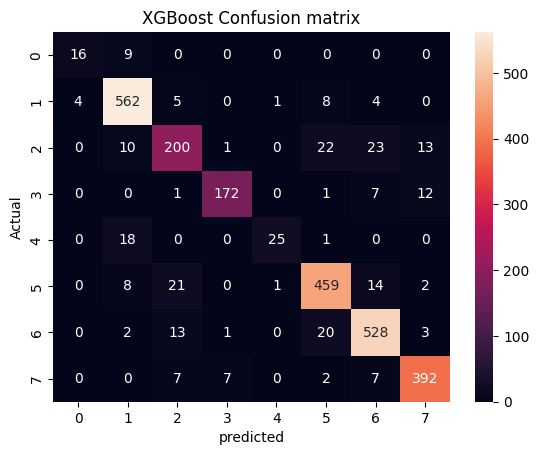

In [ ]:
heat_map = sb.heatmap(cm , annot = True , fmt = '.0f' , xticklabels = y_labels , yticklabels = y_labels)
heat_map.set_title("XGBoost Confusion matrix")
heat_map.set_xlabel("predicted")
heat_map.set_ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(y_test , y_pred_test))

              precision    recall  f1-score   support

           0       0.80      0.64      0.71        25
           1       0.92      0.96      0.94       584
           2       0.81      0.74      0.78       269
           3       0.95      0.89      0.92       193
           4       0.93      0.57      0.70        44
           5       0.89      0.91      0.90       505
           6       0.91      0.93      0.92       567
           7       0.93      0.94      0.94       415

    accuracy                           0.90      2602
   macro avg       0.89      0.82      0.85      2602
weighted avg       0.90      0.90      0.90      2602



# PrePCA

In [178]:
PRE_PCA_FILE_NAME = "Pre_PCA.csv"
PRE_PCA_PATH = os.path.join(DATA_DIR , PRE_PCA_FILE_NAME)
pre_pca_data = pd.read_csv(PCA_PATH)
pre_pca_data

,Kingdom,UUU,UUC,UUA,UUG,CUU,CUC,CUA,CUG,AUU,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,vrl,0.01654,0.01203,0.00050,0.00351,0.01203,0.03208,0.00100,0.04010,0.00551,...,0.00451,0.01303,0.03559,0.01003,0.04612,0.01203,0.04361,0.00251,0.00050,0.00000
1,vrl,0.02714,0.01357,0.00068,0.00678,0.00407,0.02849,0.00204,0.04410,0.01153,...,0.00136,0.01696,0.03596,0.01221,0.04545,0.01560,0.04410,0.00271,0.00068,0.00000
2,vrl,0.01974,0.02180,0.01357,0.01543,0.00782,0.01111,0.01028,0.01193,0.02283,...,0.00596,0.01974,0.02489,0.03126,0.02036,0.02242,0.02468,0.00391,0.00000,0.00144
3,vrl,0.01775,0.02245,0.01619,0.00992,0.01567,0.01358,0.00940,0.01723,0.02402,...,0.00366,0.01410,0.01671,0.03760,0.01932,0.03029,0.03446,0.00261,0.00157,0.00000
4,vrl,0.02816,0.01371,0.00767,0.03679,0.01380,0.00548,0.00473,0.02076,0.02716,...,0.00604,0.01494,0.01734,0.04148,0.02483,0.03359,0.03679,0.00000,0.00044,0.00131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13003,mam,0.02552,0.03555,0.00547,0.01367,0.01276,0.02097,0.00820,0.03555,0.01459,...,0.00820,0.01367,0.01094,0.01367,0.02279,0.02005,0.04102,0.00091,0.00091,0.00638
13004,mam,0.01258,0.03193,0.01984,0.00629,0.01451,0.05322,0.07644,0.01258,0.03096,...,0.00145,0.00000,0.00048,0.00194,0.01306,0.01838,0.00677,0.00242,0.00097,0.01887
13005,mam,0.01423,0.03321,0.01661,0.00356,0.01127,0.05042,0.09609,0.01068,0.02728,...,0.00000,0.00000,0.00000,0.00178,0.01661,0.02788,0.00297,0.00356,0.00119,0.02017
13006,mam,0.01757,0.02028,0.00767,0.01293,0.01319,0.01959,0.00715,0.03964,0.01600,...,0.01142,0.01217,0.01196,0.02178,0.02510,0.02896,0.03959,0.00099,0.00079,0.00156


In [182]:
X , Y = pre_pca_data.iloc[: , 1:] ,  pre_pca_data.iloc[: , 0]


In [183]:
Y = Y.map(kingdom_mapping)

In [184]:
X_train, X_test , y_train, y_test = train_test_split(X , Y , test_size = 0.2 ,  stratify = Y , random_state = 42)

In [186]:
model_grid_serach = XGBClassifier(n_estimators = 100)


param_grid = {
    'max_depth': [1, 2, 3],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}
grid_search = GridSearchCV(model_grid_serach , param_grid=param_grid , cv = 5 , scoring='f1_macro' , n_jobs = -1)

grid_search.fit(X_train.to_numpy() , y_train.to_numpy())

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=100,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.9, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [1, 2, 3], 'subsample': [0.7, 0.9, 1.0]},
             scoring='f1_macro')

In [187]:
best_parameters = grid_search.best_params_
best_parameters

{'colsample_bytree': 0.7,
 'learning_rate': 0.1,
 'max_depth': 3,
 'subsample': 0.7}

In [188]:
model_grid_serach = XGBClassifier(**best_parameters)
param_grid = {
    'n_estimators' : [100 , 150 , 200 , 250 , 300]
}
grid_search = GridSearchCV(model_grid_serach , param_grid=param_grid , cv = 5 , scoring='f1_macro' , n_jobs = -1)

grid_search.fit(X_train.to_numpy() , y_train.to_numpy())

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=0.7, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=0.1, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=3,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1, param_grid={'n_estimators': [100, 150, 200, 250, 300]},
             scoring='f1_macro')

In [189]:
grid_search.best_params_

{'n_estimators': 300}

In [190]:
model = XGBClassifier(**grid_search.best_params_, **best_parameters , reg_lambda = 2 , reg_alpha = 1)

model.fit(X_train ,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [191]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)
f1_train = f1_score(y_train , y_pred_train , average = 'macro')
f1_test = f1_score(y_test , y_pred_test , average = 'macro')

In [192]:
print(f"""
    F1-Score of training: {f1_train}

    F1-Score of test: {f1_test}
""")


    F1-Score of training: 0.9908471647178978

    F1-Score of test: 0.8860987868824836



In [193]:
y_labels = list(set(Y))
cm = confusion_matrix(y_test , y_pred_test , labels = y_labels)

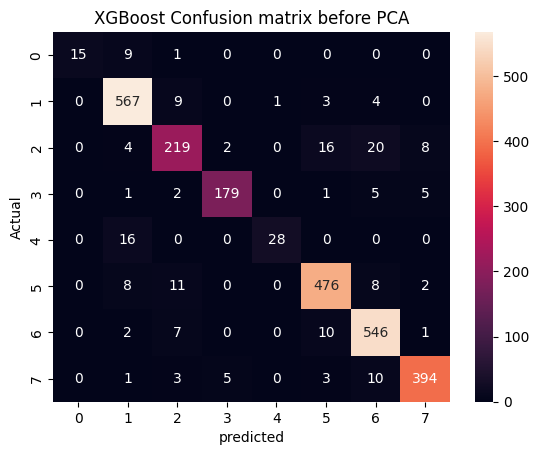

In [195]:
heat_map = sb.heatmap(cm , annot = True , fmt = '.0f' , xticklabels = y_labels , yticklabels = y_labels)
heat_map.set_title("XGBoost Confusion matrix before PCA")
heat_map.set_xlabel("predicted")
heat_map.set_ylabel("Actual")
plt.show()


In [196]:
print(classification_report(y_test , y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.60      0.75        25
           1       0.93      0.97      0.95       584
           2       0.87      0.81      0.84       269
           3       0.96      0.93      0.94       193
           4       0.97      0.64      0.77        44
           5       0.94      0.94      0.94       505
           6       0.92      0.96      0.94       566
           7       0.96      0.95      0.95       416

    accuracy                           0.93      2602
   macro avg       0.94      0.85      0.89      2602
weighted avg       0.93      0.93      0.93      2602



In [197]:
save_model(model , os.path.join(OUTPUT_PATH , 'PRE_XGBoost'))